<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG012c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

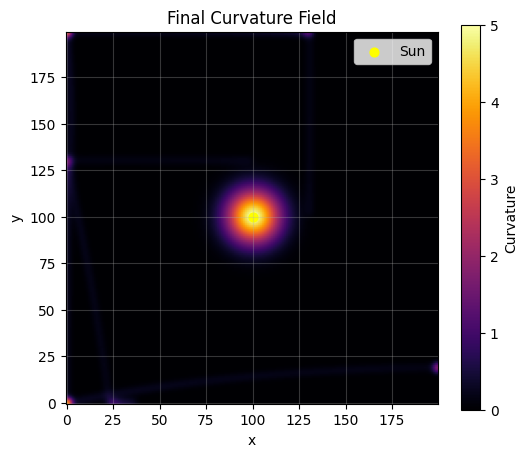

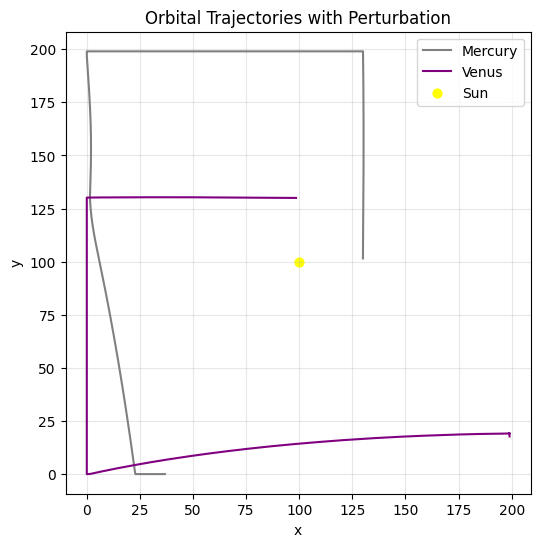

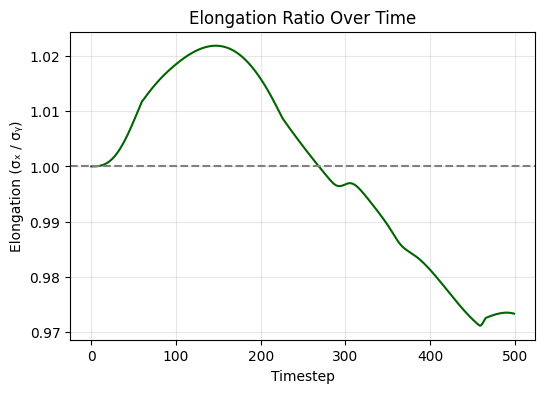

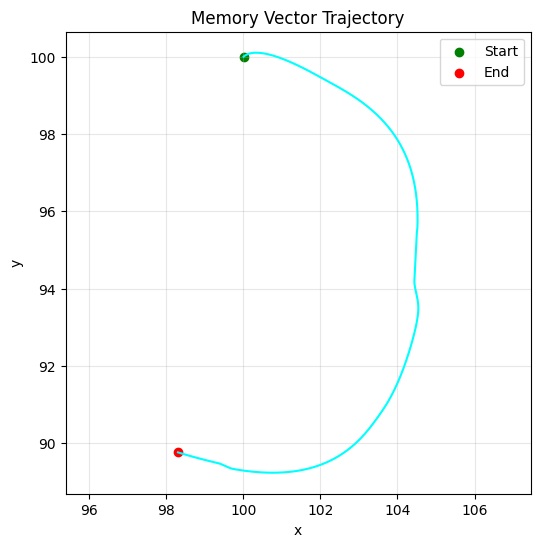

In [1]:
# TEG012C — Perturbed Mutual Memory Orbit Dynamics
# Tests basin resilience and memory recovery after orbital perturbation

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# === Parameters ===
grid_size = 200
timesteps = 500
perturb_step = 250
curvature = np.zeros((grid_size, grid_size))

# Central attractor (Sun)
A_sun = 5.0
sigma_sun = 10
sun_pos = (100, 100)

# Bodies: Mercury and Venus
bodies = {
    "Mercury": {"pos": np.array([130.0, 100.0]), "vel": np.array([0.0, 1.5]), "color": "gray"},
    "Venus": {"pos": np.array([100.0, 130.0]), "vel": np.array([-1.5, 0.0]), "color": "purple"}
}

# Curvature bump parameters for orbiting bodies
A_body = 0.05
sigma_body = 2

# Tracking
trajectories = {name: [] for name in bodies}
elongation_history = []
memory_vector_history = []

# Coordinate grid
X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))

# Add central attractor curvature
dx_sun = X - sun_pos[0]
dy_sun = Y - sun_pos[1]
curvature += A_sun * np.exp(-(dx_sun**2 + dy_sun**2) / (2 * sigma_sun**2))

# Weighted standard deviation
def weighted_std(values, weights):
    avg = np.average(values, weights=weights)
    var = np.average((values - avg)**2, weights=weights)
    return np.sqrt(var)

# === Simulation Loop ===
for t in range(timesteps):
    grad_y, grad_x = np.gradient(curvature)

    for name, body in bodies.items():
        pos = body["pos"]
        vel = body["vel"]

        ix, iy = int(pos[0]), int(pos[1])
        ix = np.clip(ix, 0, grid_size-1)
        iy = np.clip(iy, 0, grid_size-1)

        force = -np.array([grad_x[iy, ix], grad_y[iy, ix]])
        vel += 0.1 * force
        pos += vel
        pos = np.clip(pos, 0, grid_size-1)

        # Apply perturbation to Mercury at midpoint
        if name == "Mercury" and t == perturb_step:
            vel += np.array([0.5, -0.5])

        body["pos"] = pos
        body["vel"] = vel
        trajectories[name].append(pos.copy())

        dx = X - pos[0]
        dy = Y - pos[1]
        bump = A_body * np.exp(-(dx**2 + dy**2) / (2 * sigma_body**2))
        curvature += bump

    # Elongation
    x_proj = np.sum(curvature, axis=0)
    y_proj = np.sum(curvature, axis=1)
    elong_x = weighted_std(np.arange(grid_size), x_proj)
    elong_y = weighted_std(np.arange(grid_size), y_proj)
    elongation_history.append(elong_x / (elong_y + 1e-8))

    # Memory vector
    com = center_of_mass(curvature)
    memory_vector_history.append(com)

# === Plot 1: Final Curvature Field ===
plt.figure(figsize=(6,5))
plt.imshow(curvature, cmap='inferno', origin='lower')
plt.colorbar(label='Curvature')
plt.title('Final Curvature Field')
plt.xlabel('x'); plt.ylabel('y')
plt.scatter(*sun_pos, color='yellow', s=40, label='Sun')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# === Plot 2: Trajectories ===
plt.figure(figsize=(6,6))
for name, traj in trajectories.items():
    traj = np.array(traj)
    plt.plot(traj[:,0], traj[:,1], label=name, color=bodies[name]["color"])
plt.scatter(*sun_pos, color='yellow', s=40, label='Sun')
plt.title('Orbital Trajectories with Perturbation')
plt.xlabel('x'); plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

# === Plot 3: Elongation Ratio Over Time ===
plt.figure(figsize=(6,4))
plt.plot(elongation_history, color='darkgreen')
plt.title('Elongation Ratio Over Time')
plt.xlabel('Timestep'); plt.ylabel('Elongation (σₓ / σᵧ)')
plt.grid(alpha=0.3)
plt.axhline(1.0, color='gray', linestyle='--')
plt.show()

# === Plot 4: Memory Vector Trajectory ===
mem_vec = np.array(memory_vector_history)
plt.figure(figsize=(6,6))
plt.plot(mem_vec[:,0], mem_vec[:,1], color='cyan')
plt.title('Memory Vector Trajectory')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3)
plt.scatter(mem_vec[0,0], mem_vec[0,1], color='green', label='Start')
plt.scatter(mem_vec[-1,0], mem_vec[-1,1], color='red', label='End')
plt.legend()
plt.axis('equal')
plt.show()
